<a href="https://colab.research.google.com/github/Harshit-077/Animal-Face/blob/main/AnimalFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: harshskartik
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:11<00:00, 63.0MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(device)

cuda


In [3]:
image_path = []
labels = []
for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print(data_df["labels"].unique())


['cat' 'wild' 'dog']


In [4]:
train = data_df.sample(frac=0.7)
test = data_df.drop(train.index)

val = test.sample(frac=0.5)
test = test.drop(val.index)

print(train.shape)
print(val.shape)
print(test.shape)

(11291, 2)
(2420, 2)
(2419, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self, df, transform = None):
    self.df = df
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(df["labels"])).to(device)
  def __len__(self):
    return self.df.shape[0]

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx,0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label




In [7]:
train_dataset = CustomImageDataset(df = train, transform = transform)
val_dataset = CustomImageDataset(df = val, transform = transform)
test_dataset = CustomImageDataset(df = test, transform = transform)

In [8]:
train_dataset.__getitem__(0)

(tensor([[[0.3922, 0.3922, 0.3843,  ..., 0.4196, 0.4431, 0.4549],
          [0.3843, 0.3843, 0.3725,  ..., 0.3961, 0.4196, 0.4275],
          [0.3804, 0.3725, 0.3569,  ..., 0.3843, 0.3922, 0.3961],
          ...,
          [0.7333, 0.6706, 0.6196,  ..., 0.6588, 0.6392, 0.6510],
          [0.7373, 0.6627, 0.6510,  ..., 0.6157, 0.6275, 0.5843],
          [0.7490, 0.6235, 0.6314,  ..., 0.5804, 0.6235, 0.5608]],
 
         [[0.5765, 0.5765, 0.5686,  ..., 0.5882, 0.6078, 0.6235],
          [0.5686, 0.5686, 0.5569,  ..., 0.5647, 0.5922, 0.5961],
          [0.5725, 0.5647, 0.5451,  ..., 0.5569, 0.5686, 0.5725],
          ...,
          [0.7255, 0.6392, 0.5608,  ..., 0.8000, 0.7922, 0.8000],
          [0.7490, 0.6667, 0.6314,  ..., 0.7569, 0.7843, 0.7412],
          [0.7843, 0.6627, 0.6431,  ..., 0.7255, 0.7804, 0.7216]],
 
         [[0.2627, 0.2667, 0.2706,  ..., 0.3725, 0.4078, 0.4314],
          [0.2392, 0.2471, 0.2431,  ..., 0.3333, 0.3647, 0.3765],
          [0.2235, 0.2235, 0.2157,  ...,

In [9]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

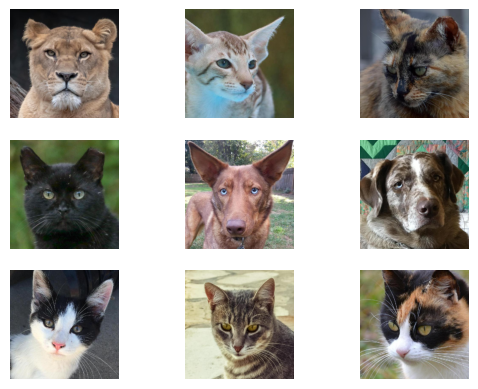

In [10]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n = 1)["image_path"].iloc[0]).convert('RGB')
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')
plt.show()

In [11]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [12]:
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [13]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size = 3, padding = 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size = 3, padding = 1)

    self.pool = nn.MaxPool2d(2,2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) # -> (32,128,128)
    x = self.pool(x)  # -> (32,64,64)
    x = self.relu(x)

    x = self.conv2(x) # -> (64,64,64)
    x = self.pool(x) # -> (64,32,32)
    x = self.relu(x)

    x = self.conv3(x) # -> (128,32,32)
    x = self.pool(x) # -> (128,16,16)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x


In [14]:
model = Net().to(device)

In [15]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR, weight_decay = 1e-4)

In [23]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

best_val_acc = 0  # for saving best model

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0

    total_loss_val = 0
    total_acc_val = 0

    # ===== TRAINING =====
    model.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        train_loss = criterion(outputs, labels)
        total_loss_train += train_loss.item()

        train_loss.backward()
        optimizer.step()

        train_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()
        total_acc_train += train_acc

    # ===== VALIDATION =====
    model.eval()
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()

            val_acc = (torch.argmax(outputs, dim=1) == labels).sum().item()
            total_acc_val += val_acc

    # ===== METRICS =====
    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss = total_loss_val / len(val_loader)

    train_accuracy = (total_acc_train / len(train_dataset)) * 100
    val_accuracy = (total_acc_val / len(val_dataset)) * 100

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_val_plot.append(round(avg_val_loss, 4))
    total_acc_train_plot.append(round(train_accuracy, 4))
    total_acc_val_plot.append(round(val_accuracy, 4))

    # ===== SAVE BEST MODEL =====
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved!")

    print(f"Epoch {epoch+1}/{EPOCHS}, "
          f"Train Loss: {round(avg_train_loss,4)}, "
          f"Train Accuracy: {round(train_accuracy,4)}, "
          f"Validation Loss: {round(avg_val_loss,4)}, "
          f"Validation Accuracy: {round(val_accuracy,4)}")

Best model saved!
Epoch 1/10, Train Loss: 0.0003, Train Accuracy: 100.0, Validation Loss: 0.1133, Validation Accuracy: 97.3967
Epoch 2/10, Train Loss: 0.0003, Train Accuracy: 100.0, Validation Loss: 0.1081, Validation Accuracy: 97.3967
Epoch 3/10, Train Loss: 0.0176, Train Accuracy: 99.38, Validation Loss: 0.1679, Validation Accuracy: 95.2893
Epoch 4/10, Train Loss: 0.0171, Train Accuracy: 99.5129, Validation Loss: 0.1139, Validation Accuracy: 96.9008
Epoch 5/10, Train Loss: 0.0032, Train Accuracy: 99.9469, Validation Loss: 0.1273, Validation Accuracy: 96.7355
Epoch 6/10, Train Loss: 0.0037, Train Accuracy: 99.9291, Validation Loss: 0.1157, Validation Accuracy: 97.1488
Epoch 7/10, Train Loss: 0.0011, Train Accuracy: 99.9911, Validation Loss: 0.1315, Validation Accuracy: 97.0661
Epoch 8/10, Train Loss: 0.0176, Train Accuracy: 99.3889, Validation Loss: 0.122, Validation Accuracy: 97.2314
Epoch 9/10, Train Loss: 0.0072, Train Accuracy: 99.7343, Validation Loss: 0.1174, Validation Accuracy

In [25]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)
    acc = (torch.argmax(predictions, dim=1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()
print(f"Accuracy Score: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/len(test_loader), 4)}")

Accuracy Score: 97.0649 and Loss is 0.1356


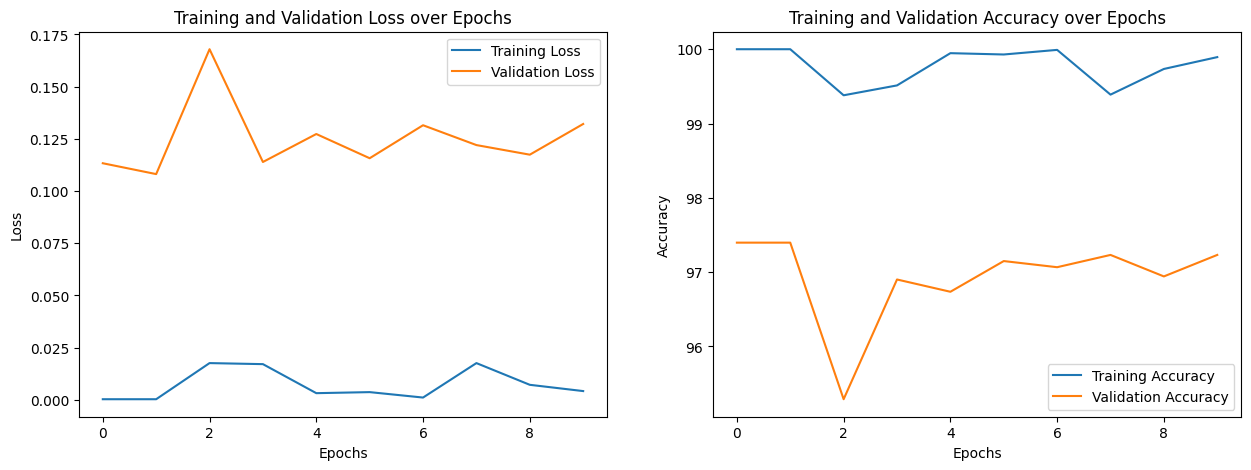

In [27]:
fig, asx = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))
asx[0].plot(total_loss_train_plot, label = "Training Loss")
asx[0].plot(total_loss_val_plot, label = "Validation Loss")
asx[0].set_title("Training and Validation Loss over Epochs")
asx[0].set_xlabel('Epochs')
asx[0].set_ylabel('Loss')
asx[0].legend()

asx[1].plot(total_acc_train_plot, label = "Training Accuracy")
asx[1].plot(total_acc_val_plot, label = "Validation Accuracy")
asx[1].set_title("Training and Validation Accuracy over Epochs")
asx[1].set_xlabel('Epochs')
asx[1].set_ylabel('Accuracy')
asx[1].legend()

plt.show()

In [42]:
# 1 Read Image
#2 Transform image
#3 predict model
#4 inverse transform

def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)
  print(image.shape)
  output = model(image.unsqueeze(0))
  print(output)
  output = torch.argmax(output, dim=1).item()
  return label_encoder.inverse_transform([output])

In [43]:
predict_image("/content/Dog_Breeds.jpg")

torch.Size([3, 128, 128])
tensor([[-3.4337,  0.8124,  0.8923]], device='cuda:0',
       grad_fn=<AddmmBackward0>)


array(['wild'], dtype=object)